# 맷플롭립 (matplotlib)

In [48]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.DataFrame([
    ['20210901', 'A', 1],
    ['20210901', 'B', 10],
    ['20210901', 'C', 100],
    ['20210902', 'A', 2],
    ['20210902', 'B', 20],
    ['20210902', 'C', 200],
    ['20210903', 'A', 3],
    ['20210903', 'B', 30],
    ['20210903', 'C', 300],
], columns = ['date', 'type', 'volume'])
df

,date,type,volume
0,20210901,A,1
1,20210901,B,10
2,20210901,C,100
3,20210902,A,2
4,20210902,B,20
5,20210902,C,200
6,20210903,A,3
7,20210903,B,30
8,20210903,C,300


In [49]:
pvt = df.pivot(index='date', columns='type', values='volume')
pvt

type,A,B,C
date,,,
20210901,1,10,100
20210902,2,20,200
20210903,3,30,300


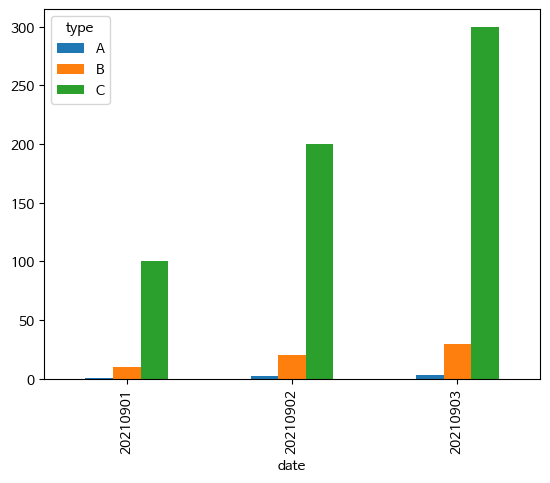

In [50]:
pvt.plot(kind='bar')
plt.show()

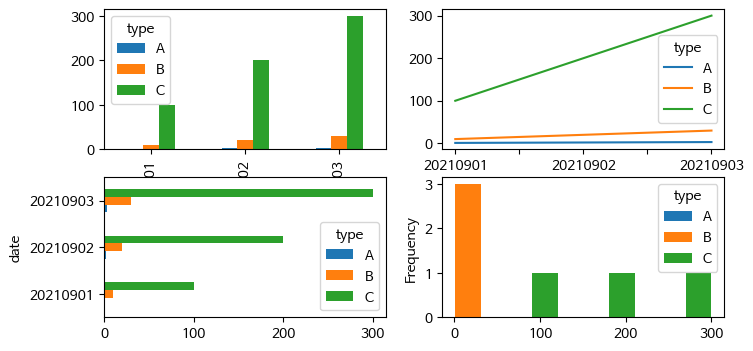

In [51]:
fig , ax = plt.subplots(2,2,figsize=(8,4))
pvt.plot(kind='bar' , ax=ax[0,0])
pvt.plot(kind='line' , ax=ax[0,1])
pvt.plot(kind='barh' , ax=ax[1,0])
pvt.plot(kind='hist' , ax=ax[1,1])
plt.show()

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    '지역':['안동','안동','안동','경기','경기','부산','서울','안동'],
    '요일':['월','월','수','월','화','월','목','금'],
    '강수확률':[80,10,90,10,20,30,40,80],
    '강수량':[80,50,100,200,20,10,50,1000],
}

df = pd.DataFrame(data)
df

,지역,요일,강수확률,강수량
0,안동,월,80,80
1,안동,월,10,50
2,안동,수,90,100
3,경기,월,10,200
4,경기,화,20,20
5,부산,월,30,10
6,서울,목,40,50
7,안동,금,80,1000


In [53]:
pd.pivot_table(
    df,
    index='요일',
    columns='지역',
    values='강수확률',
    aggfunc='max',
).fillna(' ')

지역,경기,부산,서울,안동
요일,,,,
금,,,,80.0
목,,,40.0,
수,,,,90.0
월,10.0,30.0,,80.0
화,20.0,,,


In [54]:
print(df.columns)

Index(['지역', '요일', '강수확률', '강수량'], dtype='object')


In [55]:
df.rename(columns={
    '지역':'region', '요일':'day', '강수확률':'Rain%', '강수량':'Rainfall'
}, inplace=True)

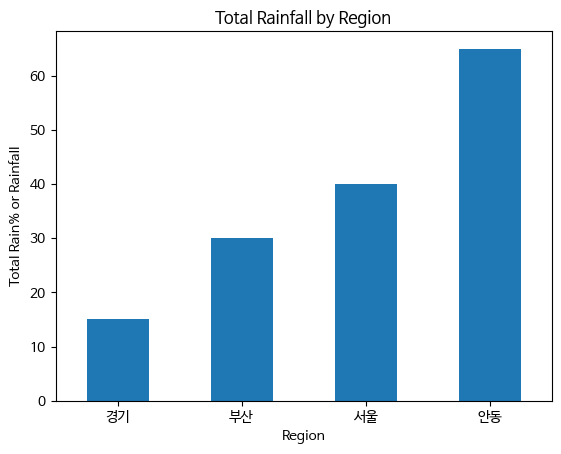

In [56]:
rain =  df.groupby("region")["Rain%"].mean()
rain.plot(kind='bar')

plt.title("Total Rainfall by Region")
plt.xlabel("Region")
plt.ylabel("Total Rain% or Rainfall")
plt.xticks(rotation=0)
plt.show()

Text(0.2, 0.4, '한글')

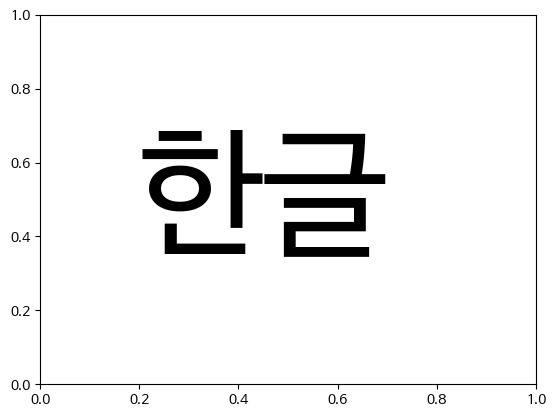

In [57]:
from matplotlib import rc
plt.rc('font', family="NanumBarunGothic")
plt.text(0.2,0.4,'한글', size=100)

### 데이터 적재 -> 정제/EDA -> 넷플릭스 Alltime 데이터 해석

In [58]:
!pwd

/home/jovyan/work


In [59]:
import pandas as pd

path = "./dataset/most-popular_global_weekly.tsv"
df = pd.read_csv(path, sep='\t')
df.head(5)
# df.tail(5)
# df.sample(5)

,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10
0,2026-05-24,Films (English),1,The Crash,NaN,43700000,1.5833,27600000.0,2
1,2026-05-24,Films (English),2,Swapped,NaN,27400000,1.7000,16100000.0,4
2,2026-05-24,Films (English),3,Ladies First,NaN,18500000,1.5500,11900000.0,1
3,2026-05-24,Films (English),4,Goat,NaN,16900000,1.6667,10100000.0,2
4,2026-05-24,Films (English),5,Remarkably Bright Creatures,NaN,15600000,1.9000,8200000.0,3


<Axes: ylabel='category'>

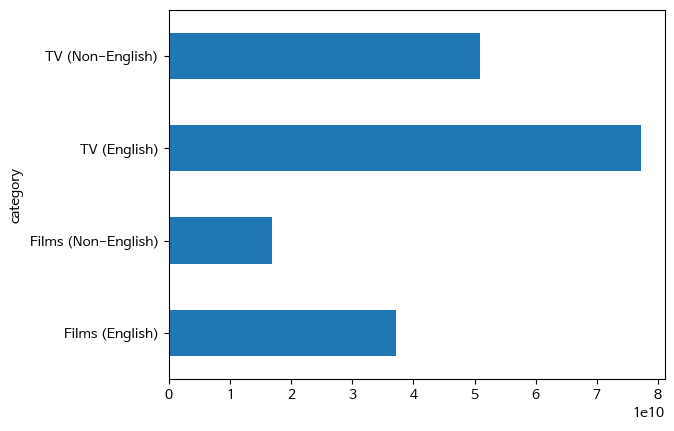

In [60]:
df.columns
df['week'] = pd.to_datetime(df['week'])
# df['week'].dtype
df.groupby('category')['weekly_hours_viewed'].sum().plot(kind='barh')

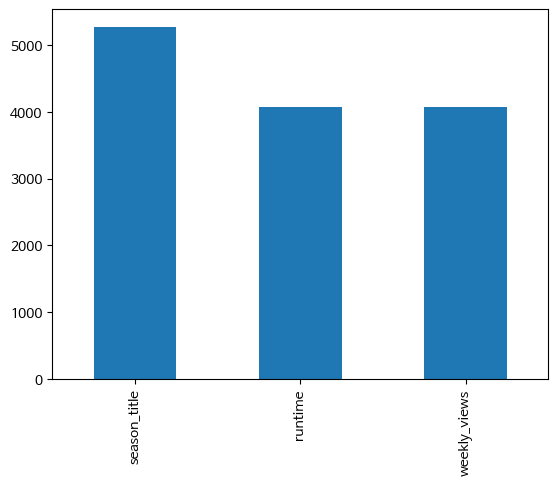

In [61]:
missing = df.isna().sum()
count = missing[missing > 0]
count.plot(kind='bar')
plt.show()

<Axes: ylabel='show_title'>

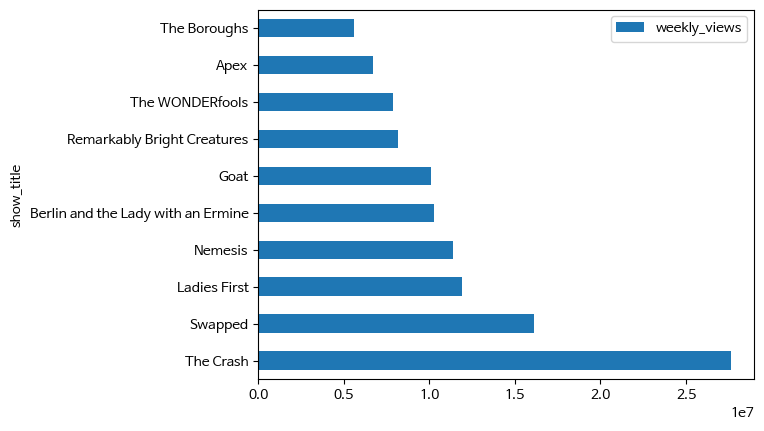

In [62]:
# 최근날짜 찾기
latest_week = df['week'].max()
latest_week

# 최근날자 뽑기
latest_df = df[df['week'] == latest_week]
week_top10 = latest_df.sort_values("weekly_views", ascending=False).head(10)
week_top10[['show_title','weekly_views']].set_index('show_title').plot(kind='barh')

### 실습

In [63]:
import numpy as np
data = {'과일이름':['apple', 'banana', 'kiwi', 'melon', 'orange', 'mango'],
        '가격': [4400, 5000, 2500, 7000, 2000, 8800],
        '갯수': [3, 8, 11, 22, 6, 5]
}
df = pd.DataFrame(data)
df

,과일이름,가격,갯수
0,apple,4400,3
1,banana,5000,8
2,kiwi,2500,11
3,melon,7000,22
4,orange,2000,6
5,mango,8800,5


In [64]:
df.index = range(1, 7)
df

,과일이름,가격,갯수
1,apple,4400,3
2,banana,5000,8
3,kiwi,2500,11
4,melon,7000,22
5,orange,2000,6
6,mango,8800,5


In [65]:
df.columns

Index(['과일이름', '가격', '갯수'], dtype='object')

In [66]:
df.values

array([['apple', 4400, 3],
       ['banana', 5000, 8],
       ['kiwi', 2500, 11],
       ['melon', 7000, 22],
       ['orange', 2000, 6],
       ['mango', 8800, 5]], dtype=object)

In [67]:
df.index.name = 'No. '
df.columns.name = 'Info'
df

Info,과일이름,가격,갯수
No.,,,
1,apple,4400,3
2,banana,5000,8
3,kiwi,2500,11
4,melon,7000,22
5,orange,2000,6
6,mango,8800,5


In [68]:
df2 = pd.DataFrame(data, columns = ['과일이름', '품종', '가격', '할인', '갯수', '합계'], index=['one', 'two', 'three', 'four', 'five', 'six'])
df2

,과일이름,품종,가격,할인,갯수,합계
one,apple,NaN,4400,NaN,3,NaN
two,banana,NaN,5000,NaN,8,NaN
three,kiwi,NaN,2500,NaN,11,NaN
four,melon,NaN,7000,NaN,22,NaN
five,orange,NaN,2000,NaN,6,NaN
six,mango,NaN,8800,NaN,5,NaN


In [69]:
df.describe()

Info,가격,갯수
count,6.000000,6.000000
mean,4950.000000,9.166667
std,2609.022806,6.853223
min,2000.000000,3.000000
25%,2975.000000,5.250000
50%,4700.000000,7.000000
75%,6500.000000,10.250000
max,8800.000000,22.000000


In [70]:
df2['품종'] = ['신선한', '유기농', '웰빙', '최적의', '가성비', '단짠']
df2['할인'] = [0.2, 0.3, 0.2, 0.1, 0.2, 0.3]
df2

,과일이름,품종,가격,할인,갯수,합계
one,apple,신선한,4400,0.2,3,NaN
two,banana,유기농,5000,0.3,8,NaN
three,kiwi,웰빙,2500,0.2,11,NaN
four,melon,최적의,7000,0.1,22,NaN
five,orange,가성비,2000,0.2,6,NaN
six,mango,단짠,8800,0.3,5,NaN


In [71]:
df2['합계'] = df2['가격'] * df2['갯수'] * (1 - df2['할인'])
df2

,과일이름,품종,가격,할인,갯수,합계
one,apple,신선한,4400,0.2,3,10560.0
two,banana,유기농,5000,0.3,8,28000.0
three,kiwi,웰빙,2500,0.2,11,22000.0
four,melon,최적의,7000,0.1,22,138600.0
five,orange,가성비,2000,0.2,6,9600.0
six,mango,단짠,8800,0.3,5,30800.0


In [72]:
# 방법1
df2['ETC'] = pd.Series([2, 3], index=['two', 'four'])
df2

# 방법2
df2['ETC2'] = ''
df2.loc['three', 'ETC2'] = 2.5
df2.loc['five', 'ETC2'] = 3.5

# 결측치 처리 방법1
# df2 = df2.fillna('')

# 결측치 처리 방법2
df2[['ETC', 'ETC2']] = df2[['ETC', 'ETC2']].astype('string')  # 문자열로 변형
df2.fillna('', inplace=True)
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400,0.2,3,10560.0,,
two,banana,유기농,5000,0.3,8,28000.0,2.0,
three,kiwi,웰빙,2500,0.2,11,22000.0,,2.5
four,melon,최적의,7000,0.1,22,138600.0,3.0,
five,orange,가성비,2000,0.2,6,9600.0,,3.5
six,mango,단짠,8800,0.3,5,30800.0,,


In [26]:
# 컬럼 삭제
del df2['ETC2']
df2

,과일이름,품종,가격,할인,갯수,합계,ETC
one,apple,신선한,4400,0.2,3,10560.0,
two,banana,유기농,5000,0.3,8,28000.0,2.0
three,kiwi,웰빙,2500,0.2,11,22000.0,
four,melon,최적의,7000,0.1,22,138600.0,3.0
five,orange,가성비,2000,0.2,6,9600.0,
six,mango,단짠,8800,0.3,5,30800.0,


In [73]:
# 판단
df[df['갯수'] >= 10]

Info,과일이름,가격,갯수
No.,,,
3,kiwi,2500,11
4,melon,7000,22


In [74]:
# 방법1 3항 연산자 효과 np.where()
df2['ETC2'] = np.where(df['갯수'] >= 10, '합격', '')

# 방법2 loc 사용
df2.loc[df2['갯수'] < 10, 'ETC'] = '보통'
df2

# 방법3 apply 사용 + lambda
df2['ETC'] = df2['갯수'].apply(lambda x: '상자' if x%2==0 else 'x')
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400,0.2,3,10560.0,x,
two,banana,유기농,5000,0.3,8,28000.0,상자,
three,kiwi,웰빙,2500,0.2,11,22000.0,x,합격
four,melon,최적의,7000,0.1,22,138600.0,상자,합격
five,orange,가성비,2000,0.2,6,9600.0,상자,
six,mango,단짠,8800,0.3,5,30800.0,x,


### LOC 실습

In [75]:
df2.loc['two':'four', '과일이름':'품종']

,과일이름,품종
two,banana,유기농
three,kiwi,웰빙
four,melon,최적의


In [76]:
df2.loc[:, ['과일이름','가격']]

,과일이름,가격
one,apple,4400
two,banana,5000
three,kiwi,2500
four,melon,7000
five,orange,2000
six,mango,8800


In [77]:
df2.loc['seven',:] = ['tomato','채소임',1100,0.2,20,1100*10*0.8,'보통','x']
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400.0,0.2,3.0,10560.0,x,
two,banana,유기농,5000.0,0.3,8.0,28000.0,상자,
three,kiwi,웰빙,2500.0,0.2,11.0,22000.0,x,합격
four,melon,최적의,7000.0,0.1,22.0,138600.0,상자,합격
five,orange,가성비,2000.0,0.2,6.0,9600.0,상자,
six,mango,단짠,8800.0,0.3,5.0,30800.0,x,
seven,tomato,채소임,1100.0,0.2,20.0,8800.0,보통,x


### iloc 실습

In [78]:
df2.iloc[3:5]

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
four,melon,최적의,7000.0,0.1,22.0,138600.0,상자,합격
five,orange,가성비,2000.0,0.2,6.0,9600.0,상자,


In [79]:
df2.iloc[3:5, 2:5]

,가격,할인,갯수
four,7000.0,0.1,22.0
five,2000.0,0.2,6.0


In [80]:
df2.iloc[[0, 2, 4], [1, 3, 4]]

,품종,할인,갯수
one,신선한,0.2,3.0
three,웰빙,0.2,11.0
five,가성비,0.2,6.0


In [81]:
df2.iloc[6,:] = ['tomato', '채소얌', 1200, 0.1, 20, 1200*0.9*10, '개꿀', 'x']
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400.0,0.2,3.0,10560.0,x,
two,banana,유기농,5000.0,0.3,8.0,28000.0,상자,
three,kiwi,웰빙,2500.0,0.2,11.0,22000.0,x,합격
four,melon,최적의,7000.0,0.1,22.0,138600.0,상자,합격
five,orange,가성비,2000.0,0.2,6.0,9600.0,상자,
six,mango,단짠,8800.0,0.3,5.0,30800.0,x,
seven,tomato,채소얌,1200.0,0.1,20.0,10800.0,개꿀,x


In [82]:
# iloc는 없는 인덱스는 생성 못함.
# df2.iloc[7,:] = ['pear', '배', 1200,0.1, 20, 1200*10*0.9, '개꿀', 'x']

### DataFrame에서의 boolean indexing

In [83]:
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400.0,0.2,3.0,10560.0,x,
two,banana,유기농,5000.0,0.3,8.0,28000.0,상자,
three,kiwi,웰빙,2500.0,0.2,11.0,22000.0,x,합격
four,melon,최적의,7000.0,0.1,22.0,138600.0,상자,합격
five,orange,가성비,2000.0,0.2,6.0,9600.0,상자,
six,mango,단짠,8800.0,0.3,5.0,30800.0,x,
seven,tomato,채소얌,1200.0,0.1,20.0,10800.0,개꿀,x


In [84]:
mask = df2['ETC'] == '합격'
# 방법1
# mask2 = (df2.columns != '품종') & (df2.columns != '할인')
# 방법2
mask2 = ~ df2.columns.isin(['품종', '할인'])
mask2

array([ True, False,  True, False,  True,  True,  True,  True])

In [85]:
df2.loc[mask, mask2]  # 합격이지만 품종과 할인컬럼은 제외

,과일이름,가격,갯수,합계,ETC,ETC2


In [86]:
df2.loc['four', '할인'] = 0.3
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400.0,0.2,3.0,10560.0,x,
two,banana,유기농,5000.0,0.3,8.0,28000.0,상자,
three,kiwi,웰빙,2500.0,0.2,11.0,22000.0,x,합격
four,melon,최적의,7000.0,0.3,22.0,138600.0,상자,합격
five,orange,가성비,2000.0,0.2,6.0,9600.0,상자,
six,mango,단짠,8800.0,0.3,5.0,30800.0,x,
seven,tomato,채소얌,1200.0,0.1,20.0,10800.0,개꿀,x


In [87]:
df2.iloc[4,4] = 12
df2

,과일이름,품종,가격,할인,갯수,합계,ETC,ETC2
one,apple,신선한,4400.0,0.2,3.0,10560.0,x,
two,banana,유기농,5000.0,0.3,8.0,28000.0,상자,
three,kiwi,웰빙,2500.0,0.2,11.0,22000.0,x,합격
four,melon,최적의,7000.0,0.3,22.0,138600.0,상자,합격
five,orange,가성비,2000.0,0.2,12.0,9600.0,상자,
six,mango,단짠,8800.0,0.3,5.0,30800.0,x,
seven,tomato,채소얌,1200.0,0.1,20.0,10800.0,개꿀,x


In [88]:
# 삭제는 drop과 del
# drop df2.drop(행이름) 한줄삭제
# del 컬럼명 해당컬럼 삭제
# 삭제보다는 왠만하면 필요한 행이나 컬럼만 고른다.

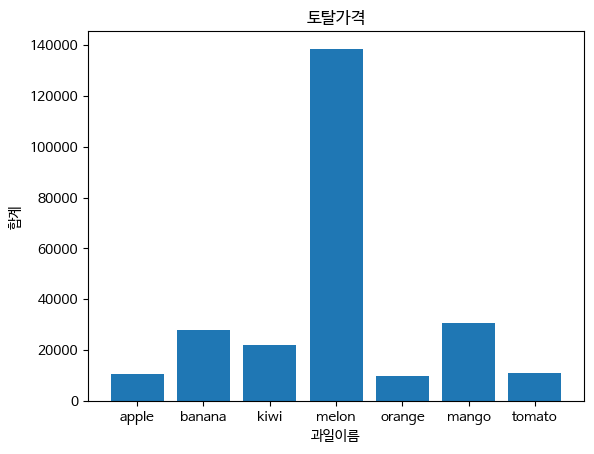

In [89]:
import matplotlib.pyplot as plt

# 방법1
# ax = df2['합계'].plot(kind='bar')
# ax.set_title('토탈가격')
# ax.set_xlabel('품종')
# ax.set_ylabel('합계')

# 방법2
plt.bar(df2['과일이름'], df2['합계'])
plt.title('토탈가격')
plt.xlabel('과일이름')
plt.ylabel('합계')

plt.show()

In [90]:
# 플롯을 2개 동시에 만들어서

# 1번째는 단가 개당 가격, 2번째는 토탈가격 넣고

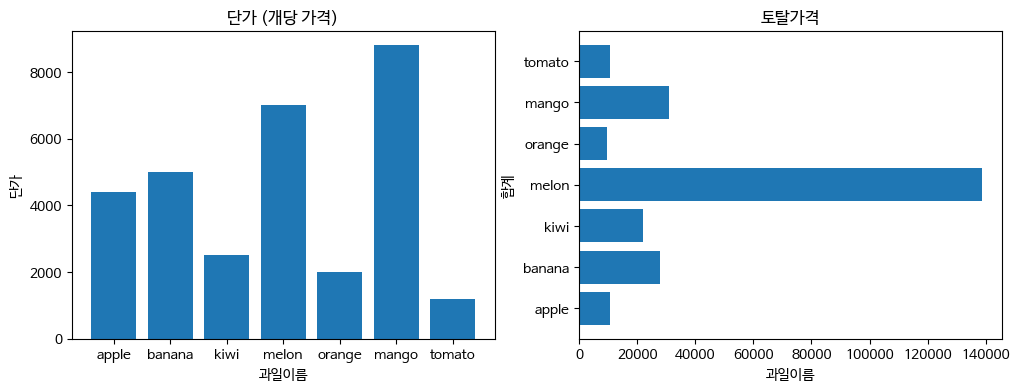

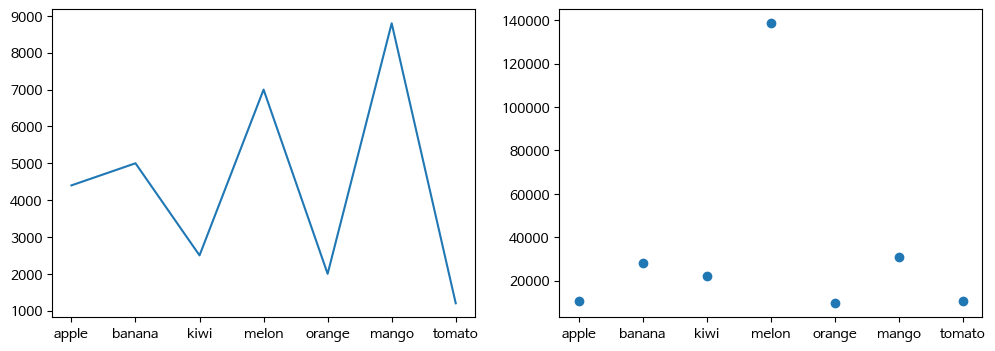

In [91]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].bar(df2['과일이름'], df2['가격'])
ax[0].set_title('단가 (개당 가격)')
ax[0].set_xlabel('과일이름')
ax[0].set_ylabel('단가')

ax[1].barh(df2['과일이름'], df2['합계'])
ax[1].set_title('토탈가격')
ax[1].set_xlabel('과일이름')
ax[1].set_ylabel('합계')

plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(df2['과일이름'], df2['가격'])
plt.subplot(1, 2, 2)
plt.scatter(df2['과일이름'], df2['합계'])
plt.show()

### 데이터실습

In [93]:
df = pd.DataFrame(np.random.randn(6,4))
np.random.seed(42)
df

,0,1,2,3
0,-1.110981,-0.519705,0.130898,-0.546034
1,0.335682,-1.209098,1.182633,-0.072664
2,1.338600,1.167362,-0.489565,0.323094
3,1.089554,-0.225632,-0.051184,0.463285
4,-1.039635,1.214985,1.011016,0.307885
5,-0.465447,-0.179496,2.070774,-0.409629


In [94]:
df.columns = ['A', 'B', 'C', 'D']
df.index = pd.date_range('20260101', periods=6)
df

,A,B,C,D
2026-01-01,-1.110981,-0.519705,0.130898,-0.546034
2026-01-02,0.335682,-1.209098,1.182633,-0.072664
2026-01-03,1.338600,1.167362,-0.489565,0.323094
2026-01-04,1.089554,-0.225632,-0.051184,0.463285
2026-01-05,-1.039635,1.214985,1.011016,0.307885
2026-01-06,-0.465447,-0.179496,2.070774,-0.409629


In [99]:
df['E'] = np.where(df['B'] > 0, True, np.nan)  # boolean으로 표현하면 True
df

,A,B,C,D,E
2026-01-01,-1.110981,-0.519705,0.130898,-0.546034,NaN
2026-01-02,0.335682,-1.209098,1.182633,-0.072664,NaN
2026-01-03,1.338600,1.167362,-0.489565,0.323094,1.0
2026-01-04,1.089554,-0.225632,-0.051184,0.463285,NaN
2026-01-05,-1.039635,1.214985,1.011016,0.307885,1.0
2026-01-06,-0.465447,-0.179496,2.070774,-0.409629,NaN


In [100]:
# 행의 값중에 하나라도 Nan인 경우 그행을 삭제한다.
df.dropna(how='any')  # , inplace=True 원본에 반영

,A,B,C,D,E
2026-01-03,1.338600,1.167362,-0.489565,0.323094,1.0
2026-01-05,-1.039635,1.214985,1.011016,0.307885,1.0


In [101]:
df.loc['2026-01-03',:] = np.nan
df

,A,B,C,D,E
2026-01-01,-1.110981,-0.519705,0.130898,-0.546034,NaN
2026-01-02,0.335682,-1.209098,1.182633,-0.072664,NaN
2026-01-03,NaN,NaN,NaN,NaN,NaN
2026-01-04,1.089554,-0.225632,-0.051184,0.463285,NaN
2026-01-05,-1.039635,1.214985,1.011016,0.307885,1.0
2026-01-06,-0.465447,-0.179496,2.070774,-0.409629,NaN


In [102]:
df.dropna(how='all')

,A,B,C,D,E
2026-01-01,-1.110981,-0.519705,0.130898,-0.546034,NaN
2026-01-02,0.335682,-1.209098,1.182633,-0.072664,NaN
2026-01-04,1.089554,-0.225632,-0.051184,0.463285,NaN
2026-01-05,-1.039635,1.214985,1.011016,0.307885,1.0
2026-01-06,-0.465447,-0.179496,2.070774,-0.409629,NaN


In [103]:
df.fillna('x')

,A,B,C,D,E
2026-01-01,-1.110981,-0.519705,0.130898,-0.546034,x
2026-01-02,0.335682,-1.209098,1.182633,-0.072664,x
2026-01-03,x,x,x,x,x
2026-01-04,1.089554,-0.225632,-0.051184,0.463285,x
2026-01-05,-1.039635,1.214985,1.011016,0.307885,1.0
2026-01-06,-0.465447,-0.179496,2.070774,-0.409629,x


In [104]:
df.isnull()

,A,B,C,D,E
2026-01-01,False,False,False,False,True
2026-01-02,False,False,False,False,True
2026-01-03,True,True,True,True,True
2026-01-04,False,False,False,False,True
2026-01-05,False,False,False,False,False
2026-01-06,False,False,False,False,True


In [105]:
df

,A,B,C,D,E
2026-01-01,-1.110981,-0.519705,0.130898,-0.546034,NaN
2026-01-02,0.335682,-1.209098,1.182633,-0.072664,NaN
2026-01-03,NaN,NaN,NaN,NaN,NaN
2026-01-04,1.089554,-0.225632,-0.051184,0.463285,NaN
2026-01-05,-1.039635,1.214985,1.011016,0.307885,1.0
2026-01-06,-0.465447,-0.179496,2.070774,-0.409629,NaN


In [107]:
# E가 결측 값인 행을 추출하여 B와 C 컬럼만 보여라.
result = df[df['E'].isnull()][['B','C']]
result

,B,C
2026-01-01,-0.519705,0.130898
2026-01-02,-1.209098,1.182633
2026-01-03,NaN,NaN
2026-01-04,-0.225632,-0.051184
2026-01-06,-0.179496,2.070774


### DataType (datetime) 전환

In [109]:
t1 = pd.date_range('20260601', periods=10)
t2 = pd.DataFrame(t1)
t2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   0       10 non-null     datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 212.0 bytes


In [110]:
print(t2.dtypes, t2[0].dtypes)

0    datetime64[ns]
dtype: object datetime64[ns]


In [114]:
print(t2[0].dt.year[0])
print(t2[0].dt.month[0])
print(t2[0].dt.day[0])
print(t2[0].dt.hour[0])
print(t2[0].dt.minute[0])
print(t2[0].dt.second[0])
print(t2[0].dt.strftime('%Y-%m-%d')[0])

2026
6
1
0
0
0
2026-06-01


### 주식정보 실습

In [116]:
# !pip install finance-datareader

In [125]:
import FinanceDataReader as fdr
df_krx = fdr.StockListing('KRX')
kospi = df_krx[df_krx['Market'] == 'KOSPI']
kospi.head(5)

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,NaN,344000,1,27000,8.52,319500,350000,319500,33149670,11200070405750,2011119841152000,5846278608,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,2346000,1,13000,0.56,2299000,2398000,2296000,4276817,10049178356000,1671999748290000,712702365,STK
2,005935,KR7005931001,삼성전자우,KOSPI,NaN,227500,1,25000,12.35,203500,235000,203000,10983971,2445136883652,182539448682500,802371203,STK
3,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1242000,1,9000,0.73,1249000,1289000,1210000,863712,1078489509000,163892315412000,131958386,STK
4,005380,KR7005380001,현대차,KOSPI,NaN,747000,1,24000,3.32,736000,783000,727000,2424200,1832625469500,152954051202000,204757766,STK


In [126]:
kospi.sort_values("Close", ascending=False).head(10)

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
26,298040,KR7298040007,효성중공업,KOSPI,NaN,3810000,1,125000,3.39,3665000,3970000,3640000,59303,230066473500,35526527880000,9324548,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,2346000,1,13000,0.56,2299000,2398000,2296000,4276817,10049178356000,1671999748290000,712702365,STK
25,000150,KR7000150003,두산,KOSPI,NaN,2244000,1,272000,13.79,2145000,2489000,2123000,195707,450430606000,36338965740000,16193835,STK
5,009150,KR7009150004,삼성전기,KOSPI,NaN,1991000,2,-136000,-6.39,2021000,2086000,1989000,1439775,2925973358500,148715148736000,74693696,STK
27,011070,KR7011070000,LG이노텍,KOSPI,NaN,1500000,1,42000,2.88,1601000,1788000,1490000,1363415,2226473872500,35500660500000,23667107,STK
13,207940,KR7207940008,삼성바이오로직스,KOSPI,NaN,1391000,1,28000,2.05,1356000,1400000,1344000,47247,64974814000,64390712841000,46290951,STK
32,010130,KR7010130003,고려아연,KOSPI,NaN,1372000,2,-1000,-0.07,1355000,1409000,1331000,19415,26797073000,28637713468000,20872969,STK
3,402340,KR7402340004,SK스퀘어,KOSPI,NaN,1242000,1,9000,0.73,1249000,1289000,1210000,863712,1078489509000,163892315412000,131958386,STK
85,003230,KR7003230000,삼양식품,KOSPI,NaN,1168000,2,-37000,-3.07,1205000,1257000,1155000,75380,89289010500,8798561520000,7533015,STK
15,012450,KR7012450003,한화에어로스페이스,KOSPI,NaN,1146000,2,-27000,-2.30,1173000,1243000,1116000,272470,318726540000,59091657546000,51563401,STK


In [134]:
kospi_sort = kospi.sort_values("ChagesRatio", ascending=False).head(10)

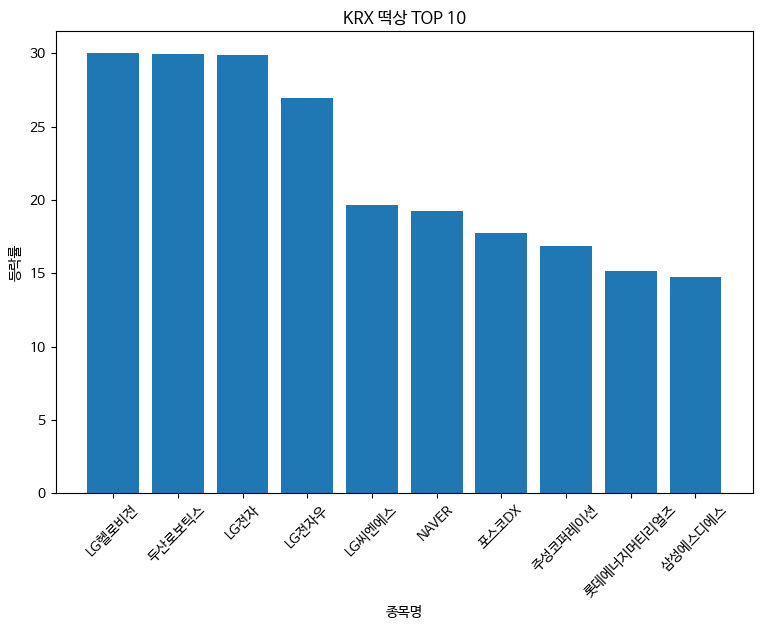

In [135]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.bar(kospi_sort['Name'], kospi_sort['ChagesRatio'])
plt.title('KRX 떡상 TOP 10')
plt.xlabel('종목명')
plt.ylabel('등락률')
plt.xticks(rotation=45)
plt.show()

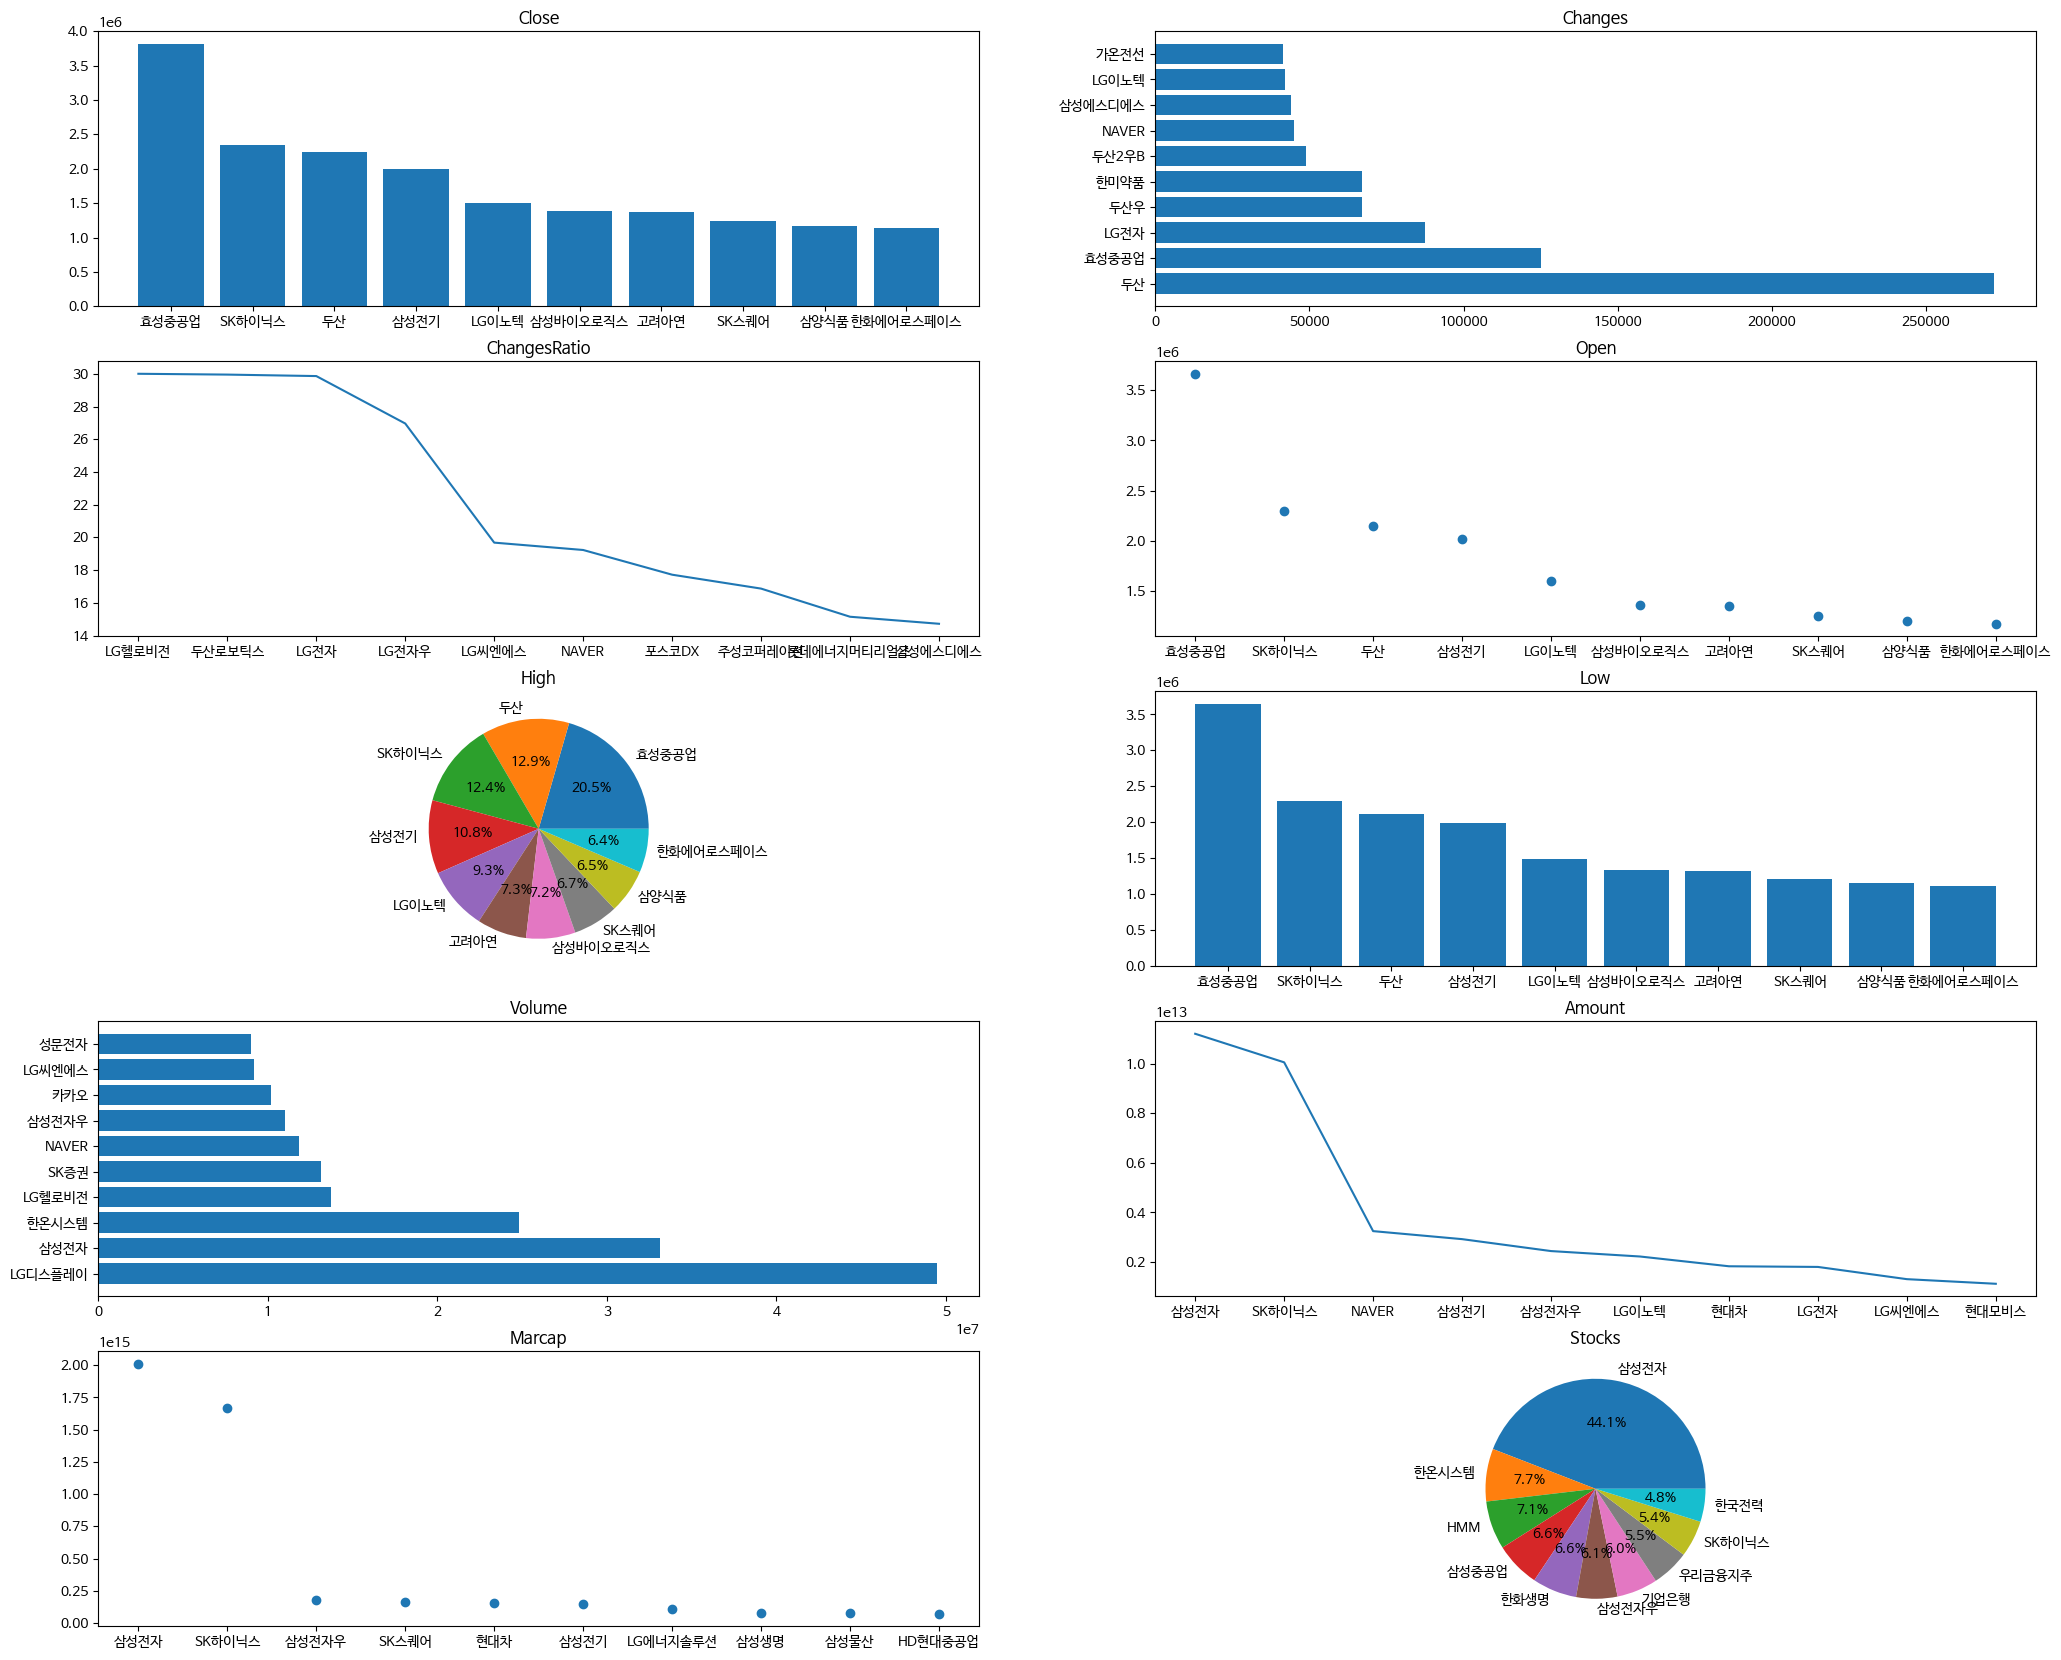

In [177]:
plt.figure(figsize=(25, 25))
kospi_sort1 = kospi.sort_values("Close", ascending=False).head(10)
kospi_sort2 = kospi.sort_values("Changes", ascending=False).head(10)
kospi_sort3 = kospi.sort_values("ChagesRatio", ascending=False).head(10)
kospi_sort4 = kospi.sort_values("Open", ascending=False).head(10)
kospi_sort5 = kospi.sort_values("High", ascending=False).head(10)
kospi_sort6 = kospi.sort_values("Low", ascending=False).head(10)
kospi_sort7 = kospi.sort_values("Volume", ascending=False).head(10)
kospi_sort8 = kospi.sort_values("Amount", ascending=False).head(10)
kospi_sort9 = kospi.sort_values("Marcap", ascending=False).head(10)
kospi_sort10 = kospi.sort_values("Stocks", ascending=False).head(10)

plt.subplot(6, 2, 1)
plt.bar(kospi_sort1['Name'], kospi_sort1['Close'])
plt.title('Close')

plt.subplot(6, 2, 2)
plt.barh(kospi_sort2['Name'], kospi_sort2['Changes'])
plt.title('Changes')

plt.subplot(6, 2, 3)
plt.plot(kospi_sort3['Name'], kospi_sort3['ChagesRatio'])
plt.title('ChangesRatio')

plt.subplot(6, 2, 4)
plt.scatter(kospi_sort4['Name'], kospi_sort4['Open'])
plt.title('Open')

plt.subplot(6, 2, 5)
plt.pie(kospi_sort5['High'], labels=kospi_sort5['Name'], autopct='%1.1f%%')
plt.title('High')

plt.subplot(6, 2, 6)
plt.bar(kospi_sort6['Name'], kospi_sort6['Low'])
plt.title('Low')

plt.subplot(6, 2, 7)
plt.barh(kospi_sort7['Name'], kospi_sort7['Volume'])
plt.title('Volume')

plt.subplot(6, 2, 8)
plt.plot(kospi_sort8['Name'], kospi_sort8['Amount'])
plt.title('Amount')

plt.subplot(6, 2, 9)
plt.scatter(kospi_sort9['Name'], kospi_sort9['Marcap'])
plt.title('Marcap')

plt.subplot(6, 2, 10)
plt.pie(kospi_sort10['Stocks'], labels=kospi_sort10['Name'], autopct='%1.1f%%')
plt.title('Stocks')

plt.show()

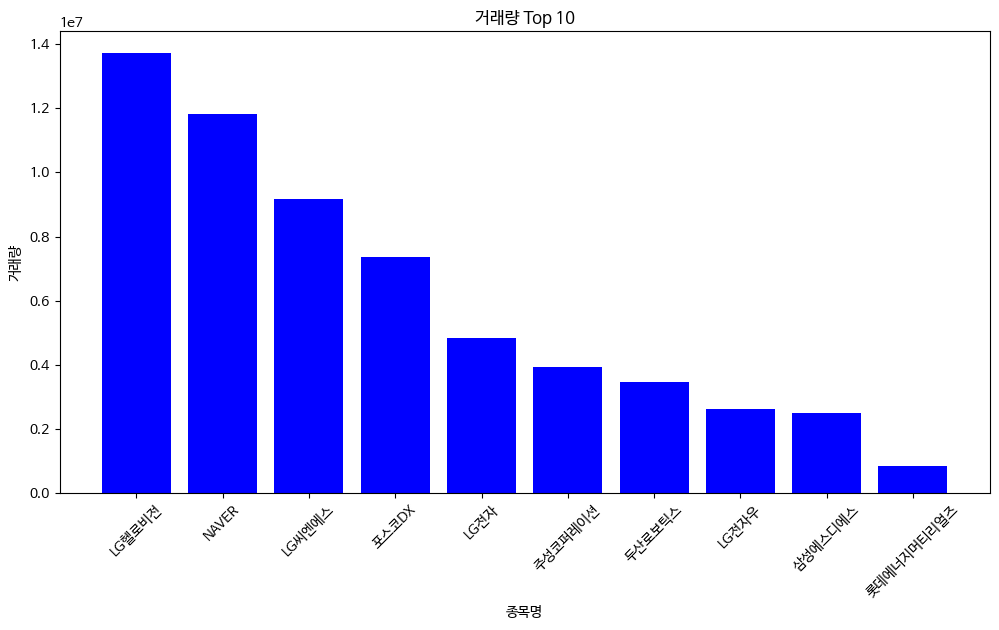

In [188]:
kospi_volume = kospi.sort_values("Volume", ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top10_volume['Name'], top10_volume['Volume'], color='blue')
plt.title('거래량 Top 10')
plt.xlabel('종목명')
plt.ylabel('거래량')
plt.xticks(rotation=45)  

plt.show()

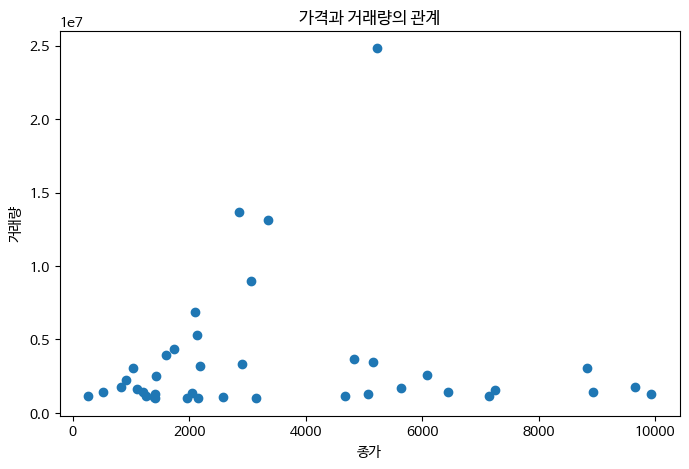

In [187]:
kospi_vc = kospi[(kospi['Volume'] > 10**6) & (kospi['Close'] < 10000)]

plt.figure(figsize=(8,5))
plt.scatter(kospi_vc['Close'], kospi_vc['Volume'])
plt.title('가격과 거래량의 관계')
plt.xlabel('종가')
plt.ylabel('거래량')
plt.show()

### openFDA API 데이터 실습

In [189]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://api.fda.gov/drug/event.json?count=patient.reaction.reactionmeddrapt.exact'
response = requests.get(url)
print(response)

<Response [200]>


In [190]:
raw = response.json()
raw.keys()

dict_keys(['meta', 'results'])

In [191]:
raw["meta"]

{'disclaimer': 'Do not rely on openFDA to make decisions regarding medical care. While we make every effort to ensure that data is accurate, you should assume all results are unvalidated. We may limit or otherwise restrict your access to the API in line with our Terms of Service.',
 'terms': 'https://open.fda.gov/terms/',
 'license': 'https://open.fda.gov/license/',
 'last_updated': '2026-04-28'}

In [192]:
df = pd.DataFrame(raw['results'])
df.head(10)

,term,count
0,DRUG INEFFECTIVE,1279733
1,DEATH,837437
2,OFF LABEL USE,835572
3,NAUSEA,763804
4,FATIGUE,753189
5,DIARRHOEA,621400
6,HEADACHE,607909
7,PAIN,599261
8,DYSPNOEA,549473
9,DIZZINESS,483161


In [193]:
df['count'].describe()

count    1.000000e+02
mean     2.468873e+05
std      1.920021e+05
min      1.081660e+05
25%      1.382430e+05
50%      1.801300e+05
75%      2.679688e+05
max      1.279733e+06
Name: count, dtype: float64

In [194]:
df10 = df.sort_values("count", ascending=False).head(10)
df10

,term,count
0,DRUG INEFFECTIVE,1279733
1,DEATH,837437
2,OFF LABEL USE,835572
3,NAUSEA,763804
4,FATIGUE,753189
5,DIARRHOEA,621400
6,HEADACHE,607909
7,PAIN,599261
8,DYSPNOEA,549473
9,DIZZINESS,483161


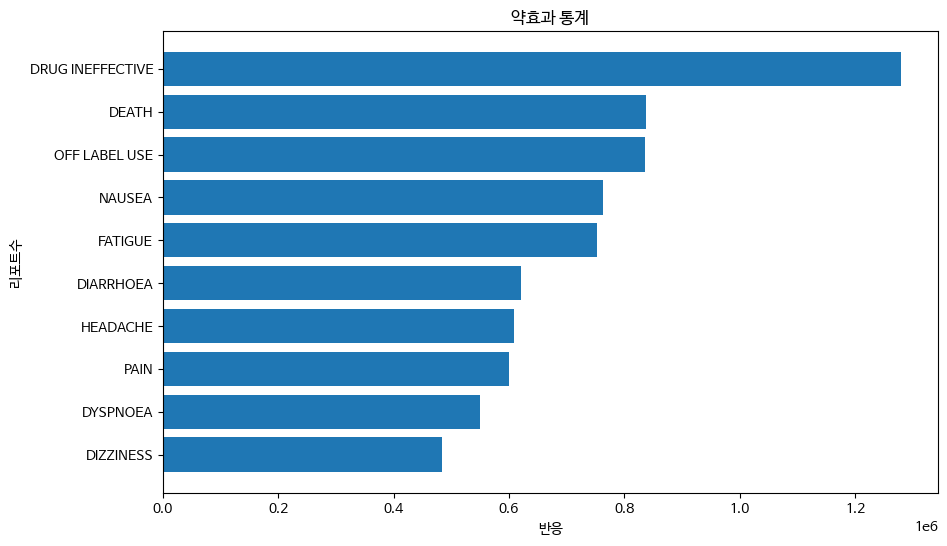

In [198]:
plt.figure(figsize=(10,6))

plt.barh(df10['term'], df10['count'])
plt.title('약효과 통계')
plt.xlabel('반응')
plt.ylabel('리포트수')
plt.gca().invert_yaxis()  # y축 뒤집기
# plt.xticks(rotation=45)
plt.show()

In [206]:
print("COVID-19가 MYOCARDIAL INFARCTION보다 많은가?")

covid = df.loc[df["term"] == 'COVID-19', 'count']
mi = df.loc[df["term"] == 'MYOCARDIAL INFARCTION', 'count']

COVID-19가 MYOCARDIAL INFARCTION보다 많은가?
